> SMH:
1. Load the dataset.
 2. Display:
 • first 10 rows
 • last 5 rows
 3. Check:
 • dataset shape
 • column data types
 4. Count:
 • total collisions
 • total injuries
 • total deaths
 5. Check for missing values.

> SMH:
6. Which city has the most collisions?
 7. Which district has the highest number of accidents?
 8. Which vehicle type is involved in the most crashes?
 9. Which weather condition has the most collisions?
 10. What percentage of collisions happen during:

 • Morning (6–12)
 • Afternoon (12–18)
 • Night (18–24)
 • Late night (0–6)

> SMH:
11. What is the average number of injuries per collision?
 12. Which vehicle type causes the most injuries?
 13. Which district has the most fatal crashes?
 14. Does higher speed limit correlate with more severe crashes?
 15. Which road condition causes the most accidents?

> SMH:
16. Create a column: time_period with values:
 • Morning
 • Afternoon
 • Evening
 • Night

> SMH:
17. Find the top 5 most dangerous districts based on fatal crashes.
 18. Calculate average delivery days for each weather condition.
(Replace delivery with collision analysis: average injuries per weather.)
 19. Create a pivot table: district vs severity
 20. Find monthly collision trends.

 
Answer:
 21. When should police increase patrols?
 22. Which district needs road safety improvements?
 23. Which vehicle type needs stricter regulations?
 24. Which weather conditions require driver warnings?
 25. Which time of day needs traffic light adjustments?



In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 3000

cities = ["Yangon","Mandalay","Naypyitaw"]
districts = ["Downtown","North","South","East","West"]

weather = ["Clear","Rain","Fog","Cloudy"]
road_condition = ["Dry","Wet","Under Construction"]
vehicle_types = ["Car","Motorcycle","Bus","Truck","Taxi"]
severity = ["Minor","Major","Fatal"]

data = pd.DataFrame({
    "collision_id": range(10001,10001+n),
    "date": pd.to_datetime("2024-01-01") + pd.to_timedelta(np.random.randint(0,365,n), unit="D"),
    "hour": np.random.randint(0,24,n),
    "city": np.random.choice(cities,n),
    "district": np.random.choice(districts,n),
    "vehicle_type": np.random.choice(vehicle_types,n),
    "weather": np.random.choice(weather,n),
    "road_condition": np.random.choice(road_condition,n),
    "num_vehicles": np.random.randint(1,5,n),
    "num_injured": np.random.randint(0,4,n),
    "num_killed": np.random.choice([0,0,0,1],n),
    "severity": np.random.choice(severity,n,p=[0.7,0.25,0.05]),
    "speed_limit": np.random.choice([40,50,60,80],n)
})

data.to_csv("traffic_collisions.csv",index=False)

print(data.head())

   collision_id       date  hour       city  district vehicle_type weather  \
0         10001 2024-04-12    10  Naypyitaw      West         Taxi     Fog   
1         10002 2024-12-14    13   Mandalay     North          Car  Cloudy   
2         10003 2024-09-27    22     Yangon  Downtown   Motorcycle  Cloudy   
3         10004 2024-04-16    15  Naypyitaw      East        Truck    Rain   
4         10005 2024-03-12     0   Mandalay     North        Truck    Rain   

       road_condition  num_vehicles  num_injured  num_killed severity  \
0                 Dry             4            3           1    Major   
1  Under Construction             4            3           1    Major   
2  Under Construction             3            3           1    Minor   
3                 Wet             4            0           0    Minor   
4                 Dry             1            2           1    Major   

   speed_limit  
0           80  
1           60  
2           60  
3           40  
4      

In [2]:
data.head()

,collision_id,date,hour,city,district,vehicle_type,weather,road_condition,num_vehicles,num_injured,num_killed,severity,speed_limit
0,10001,2024-04-12,10,Naypyitaw,West,Taxi,Fog,Dry,4,3,1,Major,80
1,10002,2024-12-14,13,Mandalay,North,Car,Cloudy,Under Construction,4,3,1,Major,60
2,10003,2024-09-27,22,Yangon,Downtown,Motorcycle,Cloudy,Under Construction,3,3,1,Minor,60
3,10004,2024-04-16,15,Naypyitaw,East,Truck,Rain,Wet,4,0,0,Minor,40
4,10005,2024-03-12,0,Mandalay,North,Truck,Rain,Dry,1,2,1,Major,40


In [3]:
data.isnull()

,collision_id,date,hour,city,district,vehicle_type,weather,road_condition,num_vehicles,num_injured,num_killed,severity,speed_limit
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,False,False,False,False,False,False,False,False,False,False,False,False,False
2996,False,False,False,False,False,False,False,False,False,False,False,False,False
2997,False,False,False,False,False,False,False,False,False,False,False,False,False
2998,False,False,False,False,False,False,False,False,False,False,False,False,False


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   collision_id    3000 non-null   int64         
 1   date            3000 non-null   datetime64[ns]
 2   hour            3000 non-null   int32         
 3   city            3000 non-null   object        
 4   district        3000 non-null   object        
 5   vehicle_type    3000 non-null   object        
 6   weather         3000 non-null   object        
 7   road_condition  3000 non-null   object        
 8   num_vehicles    3000 non-null   int32         
 9   num_injured     3000 non-null   int32         
 10  num_killed      3000 non-null   int64         
 11  severity        3000 non-null   object        
 12  speed_limit     3000 non-null   int64         
dtypes: datetime64[ns](1), int32(3), int64(3), object(6)
memory usage: 269.7+ KB


In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
data.head(10)

,collision_id,date,hour,city,district,vehicle_type,weather,road_condition,num_vehicles,num_injured,num_killed,severity,speed_limit
0,10001,2024-04-12,10,Naypyitaw,West,Taxi,Fog,Dry,4,3,1,Major,80
1,10002,2024-12-14,13,Mandalay,North,Car,Cloudy,Under Construction,4,3,1,Major,60
2,10003,2024-09-27,22,Yangon,Downtown,Motorcycle,Cloudy,Under Construction,3,3,1,Minor,60
3,10004,2024-04-16,15,Naypyitaw,East,Truck,Rain,Wet,4,0,0,Minor,40
4,10005,2024-03-12,0,Mandalay,North,Truck,Rain,Dry,1,2,1,Major,40
5,10006,2024-07-07,12,Naypyitaw,West,Truck,Fog,Dry,4,3,0,Minor,40
6,10007,2024-01-21,22,Yangon,South,Taxi,Cloudy,Wet,1,1,0,Minor,80
7,10008,2024-04-12,20,Yangon,Downtown,Car,Rain,Dry,1,1,0,Minor,40
8,10009,2024-05-01,20,Mandalay,South,Taxi,Cloudy,Dry,2,1,0,Major,60
9,10010,2024-08-02,12,Naypyitaw,East,Taxi,Rain,Dry,1,3,0,Minor,50


In [7]:
data.tail(5)

,collision_id,date,hour,city,district,vehicle_type,weather,road_condition,num_vehicles,num_injured,num_killed,severity,speed_limit
2995,12996,2024-09-02,5,Naypyitaw,East,Bus,Cloudy,Under Construction,4,1,1,Minor,50
2996,12997,2024-10-01,11,Mandalay,West,Taxi,Rain,Dry,2,0,0,Minor,80
2997,12998,2024-02-01,15,Naypyitaw,South,Truck,Fog,Dry,2,1,1,Major,40
2998,12999,2024-05-16,16,Naypyitaw,East,Car,Cloudy,Under Construction,3,0,0,Minor,60
2999,13000,2024-01-12,12,Naypyitaw,West,Motorcycle,Rain,Dry,2,2,0,Major,60


In [8]:
data.shape

(3000, 13)

In [9]:
data.dtypes

collision_id               int64
date              datetime64[ns]
hour                       int32
city                      object
district                  object
vehicle_type              object
weather                   object
road_condition            object
num_vehicles               int32
num_injured                int32
num_killed                 int64
severity                  object
speed_limit                int64
dtype: object

In [10]:
data['collision_id'].count()

np.int64(3000)

In [11]:
data['num_injured'].sum()

np.int64(4537)

In [12]:
data['num_killed'].sum()

np.int64(782)

In [13]:
data.head()


,collision_id,date,hour,city,district,vehicle_type,weather,road_condition,num_vehicles,num_injured,num_killed,severity,speed_limit
0,10001,2024-04-12,10,Naypyitaw,West,Taxi,Fog,Dry,4,3,1,Major,80
1,10002,2024-12-14,13,Mandalay,North,Car,Cloudy,Under Construction,4,3,1,Major,60
2,10003,2024-09-27,22,Yangon,Downtown,Motorcycle,Cloudy,Under Construction,3,3,1,Minor,60
3,10004,2024-04-16,15,Naypyitaw,East,Truck,Rain,Wet,4,0,0,Minor,40
4,10005,2024-03-12,0,Mandalay,North,Truck,Rain,Dry,1,2,1,Major,40


In [14]:
data.groupby('city')['collision_id'].mean().sort_values(ascending=False)

city
Yangon       11522.093656
Mandalay     11520.543330
Naypyitaw    11457.615306
Name: collision_id, dtype: float64

Yangon has the most collision.

In [15]:
data['district'].value_counts()

district
Downtown    631
North       601
West        599
South       594
East        575
Name: count, dtype: int64

Downtown is the highest number of accidents.

In [16]:
data['vehicle_type'].value_counts()

vehicle_type
Truck         631
Taxi          620
Motorcycle    600
Car           589
Bus           560
Name: count, dtype: int64

Truck is involved in the most crashes

In [17]:
data['weather'].value_counts()

weather
Fog       780
Rain      749
Cloudy    738
Clear     733
Name: count, dtype: int64

In [18]:
def Time(hour):
    if 6<=hour < 12:
        return 'Morning'
    elif 12<=hour <18:
        return 'Afternoon'
    elif 18<= hour < 24:
        return 'Night'
    else:
        return 'Late_Night'

In [19]:
data['Time_Period']=data['hour'].apply(Time)

In [20]:
data['Time_Period'].value_counts(normalize=True)*100#(Total roll count nae sar)

Time_Period
Afternoon     26.200000
Night         25.966667
Late_Night    24.200000
Morning       23.633333
Name: proportion, dtype: float64

In [21]:
data['num_injured'].mean()

np.float64(1.5123333333333333)

In [22]:
data.groupby('vehicle_type')['num_injured'].sum()

vehicle_type
Bus           808
Car           889
Motorcycle    905
Taxi          938
Truck         997
Name: num_injured, dtype: int32

Truck vehicle type causes the most injuries

In [23]:
data.groupby('district')['num_killed'].sum()

district
Downtown    161
East        158
North       165
South       158
West        140
Name: num_killed, dtype: int64

North is the most fatal crashes.

In [24]:
data.groupby(['speed_limit','severity'])['collision_id'].count()

speed_limit  severity
40           Fatal        44
             Major       209
             Minor       560
50           Fatal        30
             Major       172
             Minor       499
60           Fatal        34
             Major       211
             Minor       509
80           Fatal        45
             Major       172
             Minor       515
Name: collision_id, dtype: int64

In [25]:
data.head()

,collision_id,date,hour,city,district,vehicle_type,weather,road_condition,num_vehicles,num_injured,num_killed,severity,speed_limit,Time_Period
0,10001,2024-04-12,10,Naypyitaw,West,Taxi,Fog,Dry,4,3,1,Major,80,Morning
1,10002,2024-12-14,13,Mandalay,North,Car,Cloudy,Under Construction,4,3,1,Major,60,Afternoon
2,10003,2024-09-27,22,Yangon,Downtown,Motorcycle,Cloudy,Under Construction,3,3,1,Minor,60,Night
3,10004,2024-04-16,15,Naypyitaw,East,Truck,Rain,Wet,4,0,0,Minor,40,Afternoon
4,10005,2024-03-12,0,Mandalay,North,Truck,Rain,Dry,1,2,1,Major,40,Late_Night


In [26]:
data['road_condition'].value_counts()

road_condition
Wet                   1018
Under Construction    1012
Dry                    970
Name: count, dtype: int64

The wet road_condition is the most accidents.

In [27]:
data.groupby('road_condition')['collision_id'].size()

road_condition
Dry                    970
Under Construction    1012
Wet                   1018
Name: collision_id, dtype: int64

In [28]:
data.groupby('district')['num_killed'].sum()

district
Downtown    161
East        158
North       165
South       158
West        140
Name: num_killed, dtype: int64

North is the dangerous district. 

In [29]:
data.groupby('weather')['num_injured'].mean().sort_values(ascending=False)

weather
Rain      1.543391
Clear     1.532060
Fog       1.503846
Cloudy    1.470190
Name: num_injured, dtype: float64

In [30]:
pd.pivot_table(data,values='collision_id',index='district',columns='severity',aggfunc='count')

severity,Fatal,Major,Minor
district,,,
Downtown,27,150,454
East,41,138,396
North,27,156,418
South,27,164,403
West,31,156,412


In [31]:
data["Date"]=pd.to_datetime(data['date'])

In [32]:
data['Month'] =data['Date'].dt.month

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

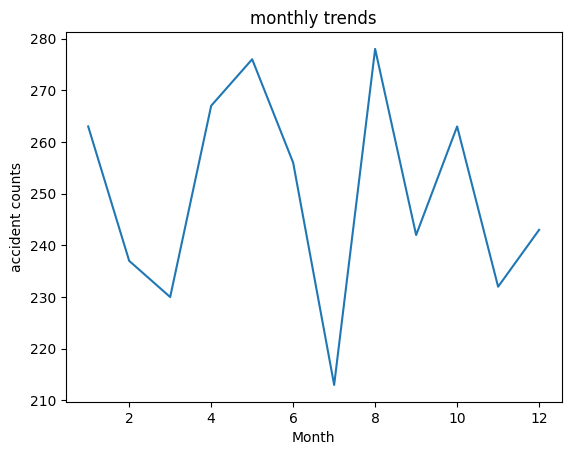

In [34]:
data.groupby('Month')['collision_id'].count().plot()
plt.xlabel('Month')
plt.ylabel('accident counts')
plt.title("monthly trends")
plt.show()

In [35]:
Severity_by_Time_Periods=data.groupby(['Time_Period','severity'])['collision_id'].count().sort_values(ascending=False).reset_index()


In [36]:
Severity_by_Time_Periods=Severity_by_Time_period.rename(columns={'collision_id':'accidents_counts'})

NameError: name 'Severity_by_Time_period' is not defined

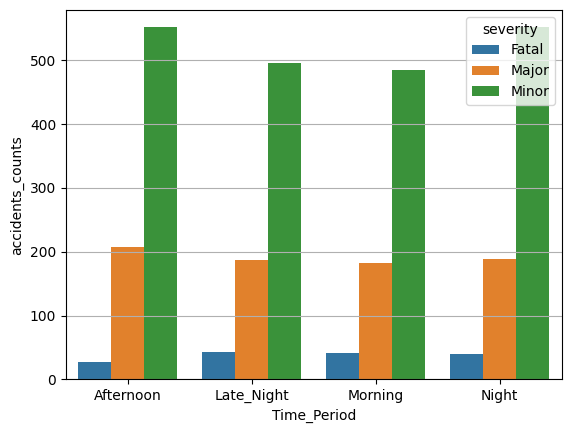

In [ ]:
import plotly.express as pe
sns.barplot(data=Severity_by_Time_Periods,x='Time_Period',y='accidents_counts',hue='severity')
plt.xlabel('Time_Period')
plt.ylabel('accidents_counts')
plt.grid(axis='y')
plt.show() 



In [ ]:
pe.bar(data_frame=Severity_by_Time_Periods,x='Time_Period',y='accidents_counts',color='severity')


The police should increase patrols at Late_Night.

In [ ]:
data.head()

,collision_id,date,hour,city,district,vehicle_type,weather,road_condition,num_vehicles,num_injured,num_killed,severity,speed_limit,Time_Period,Date,Month
0,10001,2024-04-12,10,Naypyitaw,West,Taxi,Fog,Dry,4,3,1,Major,80,Morning,2024-04-12,4
1,10002,2024-12-14,13,Mandalay,North,Car,Cloudy,Under Construction,4,3,1,Major,60,Afternoon,2024-12-14,12
2,10003,2024-09-27,22,Yangon,Downtown,Motorcycle,Cloudy,Under Construction,3,3,1,Minor,60,Night,2024-09-27,9
3,10004,2024-04-16,15,Naypyitaw,East,Truck,Rain,Wet,4,0,0,Minor,40,Afternoon,2024-04-16,4
4,10005,2024-03-12,0,Mandalay,North,Truck,Rain,Dry,1,2,1,Major,40,Late_Night,2024-03-12,3


In [ ]:
District_by_road_condition=data.groupby(['district','road_condition'])['collision_id'].count().reset_index() # no nan value 

In [ ]:
District_by_road_condition

,district,road_condition,collision_id
0,Downtown,Dry,190
1,Downtown,Under Construction,214
2,Downtown,Wet,227
3,East,Dry,189
4,East,Under Construction,195
5,East,Wet,191
6,North,Dry,187
7,North,Under Construction,209
8,North,Wet,205
9,South,Dry,209


In [ ]:
District_by_road_conditions=District_by_road_condition.rename(columns={'collision_id':'counts'})


In [ ]:
District_by_road_conditions

,district,road_condition,counts
0,Downtown,Dry,190
1,Downtown,Under Construction,214
2,Downtown,Wet,227
3,East,Dry,189
4,East,Under Construction,195
5,East,Wet,191
6,North,Dry,187
7,North,Under Construction,209
8,North,Wet,205
9,South,Dry,209


In [ ]:
fig=pe.bar(data_frame=District_by_road_conditions,x='district',y='counts',color='road_condition',title='District By Road')
fig.show()

Downtown that wet road condition needs road safety imporvements.

In [ ]:
data.head()

,collision_id,date,hour,city,district,vehicle_type,weather,road_condition,num_vehicles,num_injured,num_killed,severity,speed_limit,Time_Period,Date,Month
0,10001,2024-04-12,10,Naypyitaw,West,Taxi,Fog,Dry,4,3,1,Major,80,Morning,2024-04-12,4
1,10002,2024-12-14,13,Mandalay,North,Car,Cloudy,Under Construction,4,3,1,Major,60,Afternoon,2024-12-14,12
2,10003,2024-09-27,22,Yangon,Downtown,Motorcycle,Cloudy,Under Construction,3,3,1,Minor,60,Night,2024-09-27,9
3,10004,2024-04-16,15,Naypyitaw,East,Truck,Rain,Wet,4,0,0,Minor,40,Afternoon,2024-04-16,4
4,10005,2024-03-12,0,Mandalay,North,Truck,Rain,Dry,1,2,1,Major,40,Late_Night,2024-03-12,3


In [ ]:
stricter_by_vehicle=data.groupby(['vehicle_type','severity'])['collision_id'].count().sort_values(ascending=False).reset_index()

In [ ]:
stricter_by_vehicle=stricter_by_vehicle.rename(columns={'collision_id':'counts'})

In [ ]:
pe.bar(data_frame=stricter_by_vehicle,x='vehicle_type',y='counts',color='severity',title='stricter_by_vehicle')

Taxis need the stricter regulations

In [ ]:
Warning_depends_on_weather=data.groupby(['weather','severity'])['collision_id'].count().sort_values(ascending=False).reset_index()

In [ ]:
Warning_depends_on_weather=Warning_depends_on_weather.rename(columns={'collision_id':'counts'})

In [ ]:
pe.bar(data_frame=Warning_depends_on_weather,x='weather',y='counts',color='severity',title='warning_depend_on_weather')

Cloudy weather condition need to driver warnings

In [ ]:
Light_adjust_by_time=data.groupby(['Time_Period','severity'])['collision_id'].count().sort_values(ascending=False).reset_index()

In [ ]:
Light_adjust_by_time=Light_adjust_by_time.rename(columns={'collision_id':'counts'})

In [ ]:
pe.bar(data_frame=Light_adjust_by_time,x='Time_Period',y='counts',color='severity',title='Light_Adjustment_by_Time')

The severity fatal is the most at late_night.So,we need traffic light adjustment at Late_night.